In [2]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator


metrics_df = pd.read_csv("../data/12k_all_metrics.csv")
metrics_df["closest_ab_pident"] = metrics_df["closest_ab_pident"].fillna(0)
metrics_df["ubiquitin_pident"] = metrics_df["ubiquitin_pident"].fillna(0)

results_df = pd.read_csv("../data/12k_all_results.csv")
results_df["leah_12k_isup"] = results_df["leah_12k_2fold_threshold"] == "Up"
results_df["leah_12k_Significant"] = results_df["leah_12k_Significant"].fillna(False)
# results_df.columns
# results_df["leah_12k_2fold_threshold"].fillna("Not Sig") # I don't think we can fill the rest! and im not even sure this is valid

# # print cols with nan values
# for col in metrics_df.columns:
#     if metrics_df[col].isna().sum() > 0:
#         print(f"{col}: {metrics_df[col].isna().sum()}")

# # describe each value too
# for col in metrics_df.columns:
#     if metrics_df[col].isna().sum() > 0:
#         print(metrics_df[col].describe())
#         print()
#         print()

/tmp/ipykernel_1687609/3897468828.py:10: DtypeWarning: Columns (108) have mixed types. Specify dtype option on import or set low_memory=False.
  metrics_df = pd.read_csv("../data/12k_all_metrics.csv")
/tmp/ipykernel_1687609/3897468828.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results_df["leah_12k_Significant"] = results_df["leah_12k_Significant"].fillna(False)


In [3]:
results_df.columns

Index(['global_id', 'sequence', 'leah_12k_N6_1', 'leah_12k_R6_1',
       'leah_12k_N6_2', 'leah_12k_R6_2', 'leah_12k_N6_3', 'leah_12k_R6_3',
       'full_optimized_sequence', 'initial_orf', 'final_orf', 'leah_12k_logFC',
       'leah_12k_logCPM', 'leah_12k_LR', 'leah_12k_PValue', 'leah_12k_FDR',
       'leah_12k_2fold_threshold', 'leah_12k_Significant',
       'leah_12k_final_score', 'leah_12k_measured',
       'leah_top10_cytotox_AUC_R_CD20', 'leah_top10_cytotox_AUC_K_Control',
       'leah_top10_fold_change_CTV_MFI_AUC_proliferation',
       'leah_top10_cytotox_AUC_R_minus_K',
       'leah_top10_percent_cytokine_positive',
       'leah_top10_fold_change_total_cell_count_per_well_expansion',
       'leah_top10_cytotox_AUC_R_minus_K_minmax_norm',
       'leah_top10_percent_cytokine_positive_minmax_norm',
       'leah_top10_fold_change_total_cell_count_per_well_expansion_minmax_norm',
       'leah_top10_sum_of_norms', 'leah_12k_isup'],
      dtype='object')

In [4]:
results_df.sort_values(by="leah_12k_final_score")

,global_id,sequence,leah_12k_N6_1,leah_12k_R6_1,leah_12k_N6_2,leah_12k_R6_2,leah_12k_N6_3,leah_12k_R6_3,full_optimized_sequence,initial_orf,...,leah_top10_cytotox_AUC_K_Control,leah_top10_fold_change_CTV_MFI_AUC_proliferation,leah_top10_cytotox_AUC_R_minus_K,leah_top10_percent_cytokine_positive,leah_top10_fold_change_total_cell_count_per_well_expansion,leah_top10_cytotox_AUC_R_minus_K_minmax_norm,leah_top10_percent_cytokine_positive_minmax_norm,leah_top10_fold_change_total_cell_count_per_well_expansion_minmax_norm,leah_top10_sum_of_norms,leah_12k_isup
6398,6399,PDPQKDFEAPWISMGASINSAMVGALGAFPEMDCAMPSAQVAFIRG...,41587,3388,26725,4111,60525,3440,CCCGATCCCCAGAAGGACTTTGAAGCTCCATGGATTAGTATGGGGG...,PDPQKDFEAPWISMGASINSAMVGALGAFPEMDCAMPSAQVAFIRG...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3554,3555,STHLIKIRVPLPASARSTYYGGNDPSLFEELGLTPIYVEYAPGYVN...,482723,47569,229414,48408,346426,47675,TCTACCCACCTGATCAAAATCAGGGTTCCCCTGCCAGCCTCCGCCC...,STHLIKIRVPLPASARSTYYGGNDPSLFEELGLTPIYVEYAPGYVN...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4583,4584,EEVKLTYEQKIAKRRADIDLVKHTPLENQLAYLEAELKRLGLTAEL...,989,73,239,61,539,32,GAAGAGGTCAAACTGACTTATGAGCAAAAGATCGCCAAGCGCAGAG...,EEVKLTYEQKIAKRRADIDLVKHTPLENQLAYLEAELKRLGLTAEL...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
11185,11186,SLLSATKTFLKVLEEFKKDPEKLAKNLVKNSRGSDPSTALPEEELK...,1401,117,451,88,466,62,TCCCTCTTGAGTGCTACTAAGACCTTTCTCAAGGTCTTGGAGGAGT...,SLLSATKTFLKVLEEFKKDPEKLAKNLVKNSRGSDPSTALPEEELK...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
7721,7722,TTLLATTTVTTTAGTLTVVRAVNGTVVVSTASTPNSSTVYATSGSG...,21594,4357,15894,3559,25409,4929,ACCACATTGCTCGCTACCACCACAGTGACTACGACCGCAGGCACTC...,TTLLATTTVTTTAGTLTVVRAVNGTVVVSTASTPNSSTVYATSGSG...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11988,11989,SPRAEVARLYQDARGYLALAKANFEHGRDPMAKYSAEKAAELAKAA...,1,8,2,0,0,2,TCACCTAGGGCCGAGGTAGCCCGGCTGTACCAAGACGCAAGGGGGT...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
11993,11994,TEEAYKFYADTLKRALEKDKEEAIKTAQEMVRRIYSISDIREAAKL...,8,31,3,26,4,11,ACTGAAGAGGCCTATAAGTTCTACGCCGATACACTGAAACGCGCCC...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
11995,11996,TEEAYKFMADTLKRALEKDKEEAIKTAQEMVRRIYSISDIREAAKL...,51,179,18,137,18,73,ACTGAGGAGGCCTACAAGTTTATGGCAGATACCCTGAAGCGCGCTT...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
11998,11999,TEEAYKFIADTLKRALEKDKETAIKTAQEMVRRIYSISDIREAAKL...,6,7,0,1,2,1,ACGGAGGAGGCCTACAAATTTATCGCTGATACGCTTAAACGCGCCC...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [ ]:
from Bio.PDB import MMCIFParser
from itertools import combinations

def find_disulfides_basic(pdb_path, threshold=3.0, model_index=0):
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("prot", pdb_path)
    model = structure[model_index]

    # collect cysteines that actually have SG
    cys_residues = [
        res for res in model.get_residues()
        if res.get_resname() == "CYS" and "SG" in res
    ]

    within_chain = []
    between_chain = []

    for res1, res2 in combinations(cys_residues, 2):
        # Biopython defines Atom - Atom as Euclidean distance
        d = res1["SG"] - res2["SG"]
        if d > threshold:
            continue

        chain1 = res1.get_parent().id
        chain2 = res2.get_parent().id

        pair = (
            chain1, res1.id[1],
            chain2, res2.id[1],
        )

        # dont include BB and CC disulfides; but do include AA
        if (chain1 in ["B", "C"] and chain2 in ["B", "C"]):
            continue

        if chain1 == chain2:
            within_chain.append(pair)
        else:
            between_chain.append(pair)

    return within_chain, between_chain

disulf_df = pd.DataFrame(columns=["prot_id", "disulfide_within_chain", "disulfide_between_chain"])

for i in range(1,1000):
    prot_id = str(i).zfill(5)
    pdb_path = f"../data/jakub/data/boltz/predictions/binder{prot_id}_CD20_46-217/binder{prot_id}_CD20_46-217_model_0.cif"
    within_chain, between_chain = find_disulfides_basic(pdb_path)
    disulf_df = pd.concat([disulf_df, pd.DataFrame({
        "prot_id": [prot_id],
        "disulfide_within_chain": [within_chain],
        "disulfide_between_chain": [between_chain],
    })], ignore_index=True)

FileNotFoundError: [Errno 2] No such file or directory: '../data/jakub/data/boltz/predictions/binder00000_CD20_46-217/binder00000_CD20_46-217_model_0.cif'

In [3]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

def compute_gravy(sequence: str) -> float:
    """
    Compute GRAVY (Grand Average of Hydropathy) for an amino acid sequence.
    """
    seq = sequence.replace("*", "").upper()  # remove stop if present
    analyzed_seq = ProteinAnalysis(seq)
    return analyzed_seq.gravy()


metrics_df["gravy_score"] = metrics_df["sequence"].apply(compute_gravy)


from Bio.SeqUtils.ProtParam import ProteinAnalysis
import math

def sequence_complexity(seq):
    """
    Shannon entropy over amino acid frequencies.
    Higher entropy means higher complexity.
    """
    seq = seq.replace("*", "").upper()
    pa = ProteinAnalysis(seq)
    freqs = pa.get_amino_acids_percent()

    entropy = 0.0
    for aa, p in freqs.items():
        if p > 0:
            entropy += -p * math.log2(p)
    return entropy

metrics_df["sequence_complexity"] = metrics_df["sequence"].apply(sequence_complexity)


def num_cysteines(seq):
    """
    Count the number of cysteine residues in the sequence.
    """
    seq = seq.replace("*", "").upper()
    return seq.count('C')

metrics_df["num_cysteines"] = metrics_df["sequence"].apply(num_cysteines)

/stor/scratch/Ellington/archive/cwk687/home/micromamba/envs/dev/lib/python3.11/site-packages/Bio/SeqUtils/ProtParam.py:106: BiopythonDeprecationWarning: The get_amino_acids_percent method has been deprecated and will likely be removed from Biopython in the near future. Please use the amino_acids_percent attribute instead.
  warnings.warn(


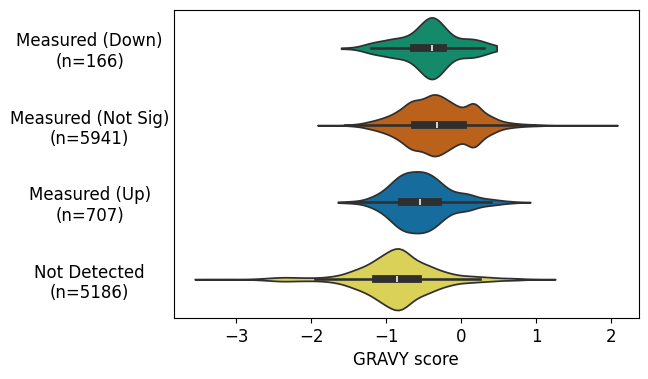

In [4]:
from scipy.stats import pearsonr
from statannotations.Annotator import Annotator
import numpy as np

# map Up / Not Sig / Down to integers
results_df["leah_12k_2fold_threshold_int"] = results_df["leah_12k_2fold_threshold"].map(
    {"Up": 1, "Not Sig": 0, "Down": -1, np.nan: np.nan}
)

# indices where we have a gravy score
metrics_df_sub = metrics_df[["gravy_score"]].dropna()

# target (yes/no measured)
measured = results_df.loc[
    metrics_df_sub.index,
    "leah_12k_measured",
]

# 3 class up/down/not sig, NaN = Not Detected
threeclass = results_df.loc[
    metrics_df_sub.index,
    "leah_12k_2fold_threshold_int",
]

# build plotting df
df = pd.DataFrame(
    {
        "gravy_score": metrics_df.loc[metrics_df_sub.index, "gravy_score"],
        "measured": measured,
    },
    index=metrics_df_sub.index,
).dropna(subset=["gravy_score", "measured"])

# add 3 class info and global_id
df["threeclass"] = threeclass.loc[df.index]
df["global_id"] = results_df.loc[df.index, "global_id"]

# map into 4 classes
def map_four_class(v):
    if pd.isna(v):
        return "Not Detected"
    if v == -1:
        return "Measured (Down)"
    if v == 0:
        return "Measured (Not Sig)"
    if v == 1:
        return "Measured (Up)"
    return "Not Detected"

df["fourclass"] = df["threeclass"].apply(map_four_class)

feature = "gravy_score"

# order for y axis
order = [
    "Measured (Down)",
    "Measured (Not Sig)",
    "Measured (Up)",
    "Not Detected",
]

palette = {
    "Measured (Down)": "#009E73",
    "Measured (Not Sig)": "#D55E00",
    "Measured (Up)": "#0072B2",
    "Not Detected": "#F0E442",
}

# ----------------- plotting -----------------
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(6, 4))

sns.violinplot(
    data=df,
    x=feature,
    y="fourclass",
    orient="h",
    order=order,
    palette=palette,
    hue="fourclass",
    ax=ax,
    cut=0,
)

valid = df["fourclass"].notna() & df[feature].notna()
dplot = df.loc[valid]
counts = dplot["fourclass"].value_counts().reindex(order).fillna(0).astype(int)

new_labels = [f"{lab}\n(n={counts[lab]})" for lab in order]

ax.set_yticks(range(len(order)))
ax.set_yticklabels(new_labels)

ax.tick_params(axis='y', length=0)
ax.set_ylabel("")
ax.set_xlabel("GRAVY score")

for label in ax.get_yticklabels():
    label.set_horizontalalignment('center')
    label.set_x(-0.17)

In [13]:
results_df.columns

Index(['global_id', 'sequence', 'leah_12k_N6_1', 'leah_12k_R6_1',
       'leah_12k_N6_2', 'leah_12k_R6_2', 'leah_12k_N6_3', 'leah_12k_R6_3',
       'full_optimized_sequence', 'initial_orf', 'final_orf', 'leah_12k_logFC',
       'leah_12k_logCPM', 'leah_12k_LR', 'leah_12k_PValue', 'leah_12k_FDR',
       'leah_12k_2fold_threshold', 'leah_12k_Significant',
       'leah_12k_final_score', 'leah_12k_measured',
       'leah_top10_cytotox_AUC_R_CD20', 'leah_top10_cytotox_AUC_K_Control',
       'leah_top10_fold_change_CTV_MFI_AUC_proliferation',
       'leah_top10_cytotox_AUC_R_minus_K',
       'leah_top10_percent_cytokine_positive',
       'leah_top10_fold_change_total_cell_count_per_well_expansion',
       'leah_top10_cytotox_AUC_R_minus_K_minmax_norm',
       'leah_top10_percent_cytokine_positive_minmax_norm',
       'leah_top10_fold_change_total_cell_count_per_well_expansion_minmax_norm',
       'leah_top10_sum_of_norms', 'leah_12k_isup',
       'leah_12k_2fold_threshold_int'],
      dtype=

       global_id  num_cysteines
5864        5865              9
1197        1198              7
982          983              6
1034        1035              6
1250        1251              6
...          ...            ...
10620      10621              0
10628      10629              0
11185      11186              0
11256      11257              0
11371      11372              0

[166 rows x 2 columns]


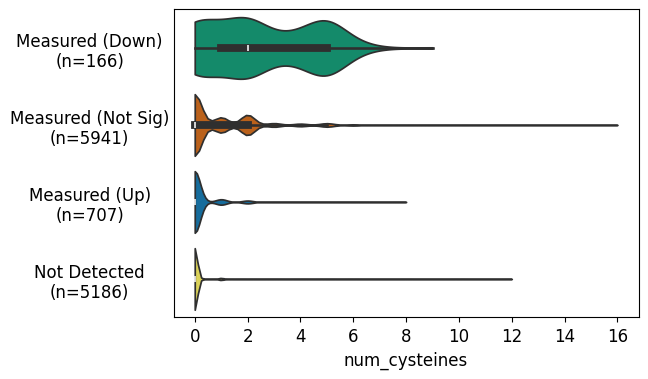

In [14]:
from scipy.stats import pearsonr
from statannotations.Annotator import Annotator
import numpy as np

# map Up / Not Sig / Down to integers
results_df["leah_12k_2fold_threshold_int"] = results_df["leah_12k_2fold_threshold"].map(
    {"Up": 1, "Not Sig": 0, "Down": -1, np.nan: np.nan}
)

# indices where we have a gravy score
metrics_df_sub = metrics_df[["num_cysteines"]].dropna()

# target (yes/no measured)
measured = results_df.loc[
    metrics_df_sub.index,
    "leah_12k_measured",
]

# 3 class up/down/not sig, NaN = Not Detected
threeclass = results_df.loc[
    metrics_df_sub.index,
    "leah_12k_2fold_threshold_int",
]

# build plotting df
df = pd.DataFrame(
    {
        "num_cysteines": metrics_df.loc[metrics_df_sub.index, "num_cysteines"],
        "measured": measured,
    },
    index=metrics_df_sub.index,
).dropna(subset=["num_cysteines", "measured"])

# add 3 class info and global_id
df["threeclass"] = threeclass.loc[df.index]
df["global_id"] = results_df.loc[df.index, "global_id"]

# map into 4 classes
def map_four_class(v):
    if pd.isna(v):
        return "Not Detected"
    if v == -1:
        return "Measured (Down)"
    if v == 0:
        return "Measured (Not Sig)"
    if v == 1:
        return "Measured (Up)"
    return "Not Detected"

df["fourclass"] = df["threeclass"].apply(map_four_class)

feature = "num_cysteines"

# order for y axis
order = [
    "Measured (Down)",
    "Measured (Not Sig)",
    "Measured (Up)",
    "Not Detected",
]

palette = {
    "Measured (Down)": "#009E73",
    "Measured (Not Sig)": "#D55E00",
    "Measured (Up)": "#0072B2",
    "Not Detected": "#F0E442",
}

# ----------------- plotting -----------------
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(6, 4))

sns.violinplot(
    data=df,
    x=feature,
    y="fourclass",
    orient="h",
    order=order,
    palette=palette,
    hue="fourclass",
    ax=ax,
    cut=0,
)

valid = df["fourclass"].notna() & df[feature].notna()
dplot = df.loc[valid]
counts = dplot["fourclass"].value_counts().reindex(order).fillna(0).astype(int)

new_labels = [f"{lab}\n(n={counts[lab]})" for lab in order]

ax.set_yticks(range(len(order)))
ax.set_yticklabels(new_labels)

ax.tick_params(axis='y', length=0)
ax.set_ylabel("")
ax.set_xlabel("num_cysteines")

for label in ax.get_yticklabels():
    label.set_horizontalalignment('center')
    label.set_x(-0.17)


# print measured down ranked by cysteine counts
measured_down = df[df["fourclass"] == "Measured (Down)"]
measured_down_sorted = measured_down.sort_values(by="num_cysteines", ascending=False)
print(measured_down_sorted[["global_id", "num_cysteines"]])

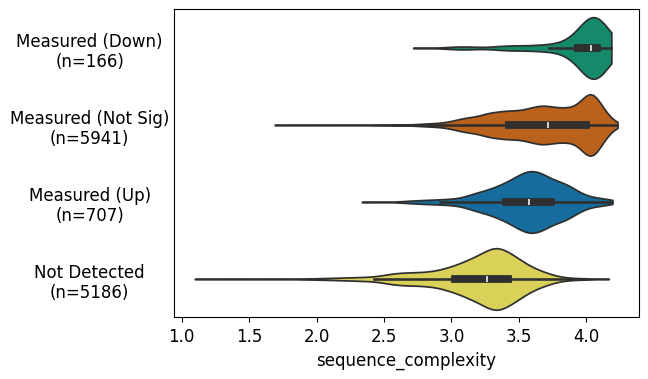

In [6]:
from scipy.stats import pearsonr
from statannotations.Annotator import Annotator
import numpy as np

# map Up / Not Sig / Down to integers
results_df["leah_12k_2fold_threshold_int"] = results_df["leah_12k_2fold_threshold"].map(
    {"Up": 1, "Not Sig": 0, "Down": -1, np.nan: np.nan}
)

# indices where we have a gravy score
metrics_df_sub = metrics_df[["sequence_complexity"]].dropna()

# target (yes/no measured)
measured = results_df.loc[
    metrics_df_sub.index,
    "leah_12k_measured",
]

# 3 class up/down/not sig, NaN = Not Detected
threeclass = results_df.loc[
    metrics_df_sub.index,
    "leah_12k_2fold_threshold_int",
]

# build plotting df
df = pd.DataFrame(
    {
        "sequence_complexity": metrics_df.loc[metrics_df_sub.index, "sequence_complexity"],
        "measured": measured,
    },
    index=metrics_df_sub.index,
).dropna(subset=["sequence_complexity", "measured"])

# add 3 class info and global_id
df["threeclass"] = threeclass.loc[df.index]
df["global_id"] = results_df.loc[df.index, "global_id"]

# map into 4 classes
def map_four_class(v):
    if pd.isna(v):
        return "Not Detected"
    if v == -1:
        return "Measured (Down)"
    if v == 0:
        return "Measured (Not Sig)"
    if v == 1:
        return "Measured (Up)"
    return "Not Detected"

df["fourclass"] = df["threeclass"].apply(map_four_class)

feature = "sequence_complexity"

# order for y axis
order = [
    "Measured (Down)",
    "Measured (Not Sig)",
    "Measured (Up)",
    "Not Detected",
]

palette = {
    "Measured (Down)": "#009E73",
    "Measured (Not Sig)": "#D55E00",
    "Measured (Up)": "#0072B2",
    "Not Detected": "#F0E442",
}

# ----------------- plotting -----------------
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(6, 4))

sns.violinplot(
    data=df,
    x=feature,
    y="fourclass",
    orient="h",
    order=order,
    palette=palette,
    hue="fourclass",
    ax=ax,
    cut=0,
)

valid = df["fourclass"].notna() & df[feature].notna()
dplot = df.loc[valid]
counts = dplot["fourclass"].value_counts().reindex(order).fillna(0).astype(int)

new_labels = [f"{lab}\n(n={counts[lab]})" for lab in order]

ax.set_yticks(range(len(order)))
ax.set_yticklabels(new_labels)

ax.tick_params(axis='y', length=0)
ax.set_ylabel("")
ax.set_xlabel("sequence_complexity")

for label in ax.get_yticklabels():
    label.set_horizontalalignment('center')
    label.set_x(-0.17)

In [9]:
# plot with native human frequencies:
human_freqs = {
    'A': 0.078,
    'C': 0.019,
    'D': 0.053,
    'E': 0.063,
    'F': 0.040,
    'G': 0.074,
    'H': 0.022,
    'I': 0.062,
    'K': 0.058,
    'L': 0.099,
    'M': 0.024,
    'N': 0.044,
    'P': 0.051,
    'Q': 0.034,
    'R': 0.052,
    'S': 0.070,
    'T': 0.058,
    'V': 0.065,
    'W': 0.013,
    'Y': 0.032,
}
from collections import Counter

# attach sequence column
df["sequence"] = results_df.loc[df.index, "sequence"]

# use the same valid mask if you like
valid = df["fourclass"].notna() & df["sequence"].notna()
dplot = df.loc[valid].copy()

aa_order = list("ACDEFGHIKLMNPQRSTVWY")

# compute AA composition per fourclass group
group_comps = {}  # group -> list of freq per aa in aa_order

for group, sub in dplot.groupby("fourclass"):
    counts = Counter()
    total_len = 0

    for seq in sub["sequence"]:
        s = seq.replace("*", "").upper()
        counts.update(s)
        total_len += len(s)

    if total_len == 0:
        freqs = [0.0] * len(aa_order)
    else:
        freqs = [counts[aa] / total_len for aa in aa_order]

    group_comps[group] = freqs



# ----------------- grouped barplot -----------------
# ----------------- grouped barplot with human frequencies -----------------
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(12, 4))

x = np.arange(len(aa_order))
width = 0.15  # slightly narrower to fit 5 bars

# first plot your 4 groups
for i, group in enumerate(order):
    freqs = group_comps.get(group, [0.0] * len(aa_order))
    ax.bar(
        x + (i - 2) * width,   # shift for 5 total bars (centered)
        freqs,
        width=width,
        label=group,
        color=palette.get(group, None),
        edgecolor="black",
        linewidth=0.3,
    )

# now add human frequencies as the 5th bar set
human_freq_list = [human_freqs[aa] for aa in aa_order]

ax.bar(
    x + (4 - 2) * width,  # index 4 of 5, centered shift
    human_freq_list,
    width=width,
    label="Human Proteome",
    color="gray",
    edgecolor="black",
    linewidth=0.3,
)

ax.set_xticks(x)
ax.set_xticklabels(aa_order)
ax.set_ylabel("Fraction")
ax.set_xlabel("Amino acid")
ax.set_title("AA composition by group (with human reference)")
ax.legend(title="Group", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(
    "../results/analysis/aa_composition_by_group_with_human.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close(fig)

In [33]:
# results_df[~results_df["leah_12k_measured"]][["leah_12k_N6_1", "leah_12k_N6_2", "leah_12k_N6_3", "leah_12k_R6_1", "leah_12k_R6_2", "leah_12k_R6_3"]].describe()
combined_df = metrics_df.merge(results_df, on=["global_id", "sequence"])

# combined_df[combined_df["esm2_full_LL_target"] > -150]["leah_12k_measured"].value_counts()
combined_df["leah_12k_2fold_threshold"] = combined_df["leah_12k_2fold_threshold"].fillna("NaN")
combined_df[combined_df["esm2_full_LL_target"] > -150]["leah_12k_2fold_threshold"].value_counts()

def contains_linker(seq):
    return "GGGS" in seq or "SSGSG" in seq or "GSGSG" in seq

def contains_repeat(seq):
    "contains a stretch of 4 characters in a row"
    for i in range(len(seq) - 3):
        if seq[i] == seq[i+1] == seq[i+2] == seq[i+3]:
            return True
    return False

combined_df["contains_linker"] = combined_df["sequence"].apply(contains_linker)
combined_df["contains_repeat"] = combined_df["sequence"].apply(contains_repeat)


# print gravy by group
gravy_stats = combined_df.groupby("leah_12k_2fold_threshold")["gravy"].describe()
print("GRAVY stats by leah_12k_2fold_threshold:")
print(gravy_stats)
print()

removed_df = pd.DataFrame()

# combined_df[combined_df["esm2_full_LL_target"] > -150][["global_id", "sequence", "esm2_full_LL_target", "leah_12k_measured", "leah_12k_2fold_threshold", "msa_depth", "closest_ab", "contains_linker"]].sort_values(by=["leah_12k_2fold_threshold", "esm2_full_LL_target"]).to_csv("_tmp_goodesm.csv", index=False)

print("Initial:")
print(f"Total seqs: {len(combined_df)}")
print(combined_df["leah_12k_2fold_threshold"].value_counts())
print()

print("ESM2 LL > -150:")
combined_df = combined_df[combined_df["esm2_full_LL_target"] > -150].reset_index(drop=True)
print(f"Total seqs: {len(combined_df)}")
print(combined_df["leah_12k_2fold_threshold"].value_counts())
print()

print("mean boltz_rosetta_A_BC_complex_normalized")
print(combined_df["boltz_rosetta_A_BC_complex_normalized"].describe())

print("Removing seqs with GGGS, SSGSG, GSGSG linkers:")
removed_df = pd.concat([removed_df, combined_df[combined_df["contains_linker"]]])
combined_df = combined_df[~combined_df["contains_linker"]].reset_index(drop=True)
print(f"Total seqs: {len(combined_df)}")
print(combined_df["leah_12k_2fold_threshold"].value_counts())
print()

print("Removing seqs with any ab homology:")
removed_df = pd.concat([removed_df, combined_df[combined_df["closest_ab_pident"] > 0]])
combined_df = combined_df[combined_df["closest_ab_pident"] == 0].reset_index(drop=True)
print(f"Total seqs: {len(combined_df)}")
print(combined_df["leah_12k_2fold_threshold"].value_counts())
print()

print("Removing seqs with stretch of 4+ same character in a row:")
removed_df = pd.concat([removed_df, combined_df[combined_df["contains_repeat"]]])
combined_df = combined_df[~combined_df["contains_repeat"]].reset_index(drop=True)
print(f"Total seqs: {len(combined_df)}")
print(combined_df["leah_12k_2fold_threshold"].value_counts())
print()


combined_df[["global_id", "sequence", "esm2_full_LL_target", "boltz_rosetta_A_BC_complex_normalized", "leah_12k_measured", "leah_12k_2fold_threshold", "msa_depth",]].sort_values(by=["leah_12k_2fold_threshold", "esm2_full_LL_target"]).to_csv("_tmp_goodesm.csv", index=False)
removed_df[["global_id", "sequence", "esm2_full_LL_target", "boltz_rosetta_A_BC_complex_normalized", "leah_12k_measured", "leah_12k_2fold_threshold", "msa_depth", "closest_ab_pident", "contains_linker", "contains_repeat"]].sort_values(by=["leah_12k_2fold_threshold", "esm2_full_LL_target"]).to_csv("_tmp_removed.csv", index=False)

GRAVY stats by leah_12k_2fold_threshold:
                           count      mean       std      min       25%  \
leah_12k_2fold_threshold                                                  
Down                       166.0 -0.422613  0.393079 -1.60375 -0.632813   
NaN                       5186.0 -0.874666  0.572579 -3.55500 -1.132500   
Not Sig                   5941.0 -0.303298  0.447619 -1.91875 -0.622500   
Up                         707.0 -0.523596  0.387711 -1.64750 -0.787500   

                               50%      75%      max  
leah_12k_2fold_threshold                              
Down                     -0.398125 -0.24750  0.47000  
NaN                      -0.856250 -0.57875  1.25125  
Not Sig                  -0.323750  0.01625  2.08125  
Up                       -0.557500 -0.30875  0.91750  

Initial:
Total seqs: 12000
leah_12k_2fold_threshold
Not Sig    5941
NaN        5186
Up          707
Down        166
Name: count, dtype: int64

ESM2 LL > -150:
Total seqs: 1566
l

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# order of categories on the y axis
order = ["Down", "Not Sig", "Up", "NaN"]

def plot_gravy_vs_threshold(df, subset_name, outpath):
    # drop rows without gravy or threshold label
    dplot = df[["gravy", "leah_12k_2fold_threshold"]].dropna(subset=["gravy", "leah_12k_2fold_threshold"])

    plt.rcParams.update({'font.size': 12})
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.violinplot(
        data=dplot,
        x="gravy",
        y="leah_12k_2fold_threshold",
        orient="h",
        order=order,
        cut=0,
        ax=ax,
    )

    ax.set_xlabel("GRAVY score")
    ax.set_ylabel("leah_12k_2fold_threshold")
    ax.set_title(f"GRAVY by 2-fold category ({subset_name})")

    plt.tight_layout()
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# plot for combined_df
plot_gravy_vs_threshold(
    combined_df,
    subset_name="kept",
    outpath="../results/analysis/gravy_by_2fold_kept.png",
)

# plot for removed_df
plot_gravy_vs_threshold(
    removed_df,
    subset_name="removed",
    outpath="../results/analysis/gravy_by_2fold_removed.png",
)

In [122]:
cols = metrics_df.columns.drop(["team", "global_id", "sequence", "closest_ab"]).tolist()

mi_df = pd.DataFrame()
for col in cols:
    pre_len = len(metrics_df)
    metrics_df_col = metrics_df[[col]].copy()
    metrics_df_col = metrics_df_col[~metrics_df_col[col].isna()]
    post_len = len(metrics_df_col)
    X = metrics_df_col[col].values.reshape(-1, 1)
    y = results_df.loc[metrics_df_col.index, "leah_12k_measured"].values
    mi = mutual_info_classif(
        X,
        y,
        random_state=8387234,
        # n_neighbors=5,
        # discrete_features=False,
    )
    sub_df = pd.DataFrame({
        "metric": col,
        "mi_vs_leah_12k_measured": mi,
        "num_non_nan": post_len,
        "num_nan": pre_len - post_len,
    })
    mi_df = pd.concat([mi_df, sub_df], axis=0)


In [123]:
mi_df = mi_df.sort_values("mi_vs_leah_12k_measured", ascending=False).reset_index(drop=True)
mi_df.to_csv("../results/analysis/feature_mi_vs_leah_12k_measured.csv", index=False)

In [124]:
# from scipy.stats import pearsonr
# from statannotations.Annotator import Annotator

# results_df["leah_12k_2fold_threshold_int"] = results_df["leah_12k_2fold_threshold"].map(
#     {"Up": 1, "Not Sig": 0, "Down": -1, np.nan: np.nan}
# )

# # list of features
# feat_list = ["esm2_full_LL_target", "boltz_rosetta_A_BC_complex_normalized"]

# # sign for each feature in the same order
# sign_list = [-1.0, 1.0]

# metrics_df_sub = metrics_df[feat_list].copy()
# metrics_df_sub = metrics_df_sub.dropna()

# # z score normalize each feature
# metrics_df_norm = (metrics_df_sub - metrics_df_sub.mean()) / metrics_df_sub.std()

# # signed weighted sum for all features
# joint_score = (metrics_df_norm.values * sign_list).sum(axis=1)

# # target (yes/no measured)
# measured = results_df.loc[
#     metrics_df_sub.index,
#     "leah_12k_measured",
# ]

# # 3 class up/down/not sig, NaN = Not Detected
# threeclass = results_df.loc[
#     metrics_df_sub.index,
#     "leah_12k_2fold_threshold_int",
# ]

# # build plotting df, keep index for alignment
# df = pd.DataFrame(
#     {
#         "joint_score": joint_score,
#         "measured": measured,
#     },
#     index=metrics_df_sub.index,
# ).dropna(subset=["joint_score", "measured"])

# # attach 3 class info on same index
# df["threeclass"] = threeclass.loc[df.index]

# # 4 class label
# def map_four_class(v):
#     if pd.isna(v):
#         return "Not Detected"
#     if v == -1:
#         return "Measured (Down)"
#     if v == 0:
#         return "Measured (Not Sig)"
#     if v == 1:
#         return "Measured (Up)"
#     return "Not Detected"  # fallback

# df["fourclass"] = df["threeclass"].apply(map_four_class)

# feature = "joint_score"

# # order for y axis (top to bottom)
# order = [
#     "Measured (Down)",
#     "Measured (Not Sig)",
#     "Measured (Up)",
#     "Not Detected",
# ]

# # palette: white, gray, red, blue
# palette = {
#     "Measured (Down)": "#3C53C5",
#     "Measured (Not Sig)": "#6EAE6F",
#     "Measured (Up)": "#D97277",
#     "Not Detected": "#BEBEBE",   # white
# }

# # -------- MI and Pearson vs measured --------
# X_joint = df[feature].values.reshape(-1, 1)
# y_joint = df["measured"].values

# mi_joint = mutual_info_classif(
#     X_joint,
#     y_joint,
#     random_state=169873,
# )[0]
# print("MI:", mi_joint)

# pearson_corr, pearson_pval = pearsonr(df[feature].values, y_joint)
# print("Pearson:", pearson_corr, pearson_pval)

# # ----------------- plotting -----------------
# plt.rcParams.update({'font.size': 12})
# fig, ax = plt.subplots(figsize=(6, 4))

# sns.violinplot(
#     data=df,
#     x=feature,
#     y="fourclass",
#     orient="h",
#     order=order,
#     palette=palette,
#     hue="fourclass",
#     ax=ax,
#     cut=0,
# )

# # counts based on actually plotted data
# valid = df["fourclass"].notna() & df[feature].notna()
# dplot = df.loc[valid]
# counts = dplot["fourclass"].value_counts().reindex(order).fillna(0).astype(int)

# # y tick labels with counts
# new_labels = [f"{lab}\n(n={counts[lab]})" for lab in order]

# ax.set_yticks(range(len(order)))
# ax.set_yticklabels(new_labels)



# ax.tick_params(axis='y', length=0)
# ax.set_ylabel("")
# ax.set_xlabel("Joint Score")

# # center the y tick text and move it slightly left
# for label in ax.get_yticklabels():
#     label.set_horizontalalignment('center')
#     label.set_x(-0.17)

# # bracket-style stars: all pairwise comparisons across 4 groups
# from itertools import combinations
# # pairs = list(combinations(order, 2))
# pairs = [
#     ("Measured (Down)", "Measured (Not Sig)"),
#     ("Measured (Not Sig)", "Measured (Up)"),
#     ("Measured (Up)", "Not Detected"),]

# annotator = Annotator(
#     ax,
#     pairs,
#     data=dplot,
#     x=feature,
#     y="fourclass",
#     order=order,
#     orient="h",
# )
# annotator.configure(
#     test="Mann-Whitney",
#     comparisons_correction="BH",
#     text_format="star",
#     pvalue_thresholds=[(1e-4, "****"), (1e-3, "***"), (1e-2, "**"), (0.05, "*"), (1, "ns")],
#     show_test_name=False,
#     loc="outside",
#     fontsize=11,
#     hide_non_significant=False,
# )
# annotator.apply_and_annotate()

# plt.savefig(
#     f"../results/analysis/feature_joint_score_by_4class_measured.png",
#     dpi=300,
#     bbox_inches='tight',
# )

MI: 0.25600743909866264
Pearson: 0.581877294959525 0.0


/tmp/ipykernel_3008910/605989994.py:150: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Measured (Down) vs. Measured (Not Sig): Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.051e-23 U_stat=4.325e+05
Measured (Not Sig) vs. Measured (Up): Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.101e-19 U_stat=1.695e+06
Measured (Up) vs. Not Detected: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.040e-164 U_stat=2.407e+06


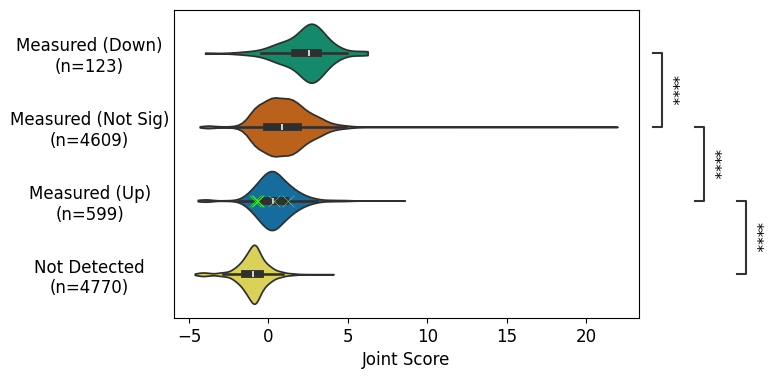

In [125]:
from scipy.stats import pearsonr
from statannotations.Annotator import Annotator
import numpy as np

results_df["leah_12k_2fold_threshold_int"] = results_df["leah_12k_2fold_threshold"].map(
    {"Up": 1, "Not Sig": 0, "Down": -1, np.nan: np.nan}
)

# list of features
feat_list = ["esm2_full_LL_target", "boltz_rosetta_A_BC_complex_normalized"]

# sign for each feature in the same order
sign_list = [-1.0, 1.0]

metrics_df_sub = metrics_df[feat_list].copy()
metrics_df_sub = metrics_df_sub.dropna()

# z score normalize each feature
metrics_df_norm = (metrics_df_sub - metrics_df_sub.mean()) / metrics_df_sub.std()

# signed weighted sum for all features
joint_score = (metrics_df_norm.values * sign_list).sum(axis=1)

# target (yes/no measured)
measured = results_df.loc[
    metrics_df_sub.index,
    "leah_12k_measured",
]

# 3 class up/down/not sig, NaN = Not Detected
threeclass = results_df.loc[
    metrics_df_sub.index,
    "leah_12k_2fold_threshold_int",
]

# build plotting df, keep index for alignment
df = pd.DataFrame(
    {
        "joint_score": joint_score,
        "measured": measured,
    },
    index=metrics_df_sub.index,
).dropna(subset=["joint_score", "measured"])

# attach 3 class info and global_id on same index
df["threeclass"] = threeclass.loc[df.index]
df["global_id"] = results_df.loc[df.index, "global_id"]

# 4 class label
def map_four_class(v):
    if pd.isna(v):
        return "Not Detected"
    if v == -1:
        return "Measured (Down)"
    if v == 0:
        return "Measured (Not Sig)"
    if v == 1:
        return "Measured (Up)"
    return "Not Detected"  # fallback

df["fourclass"] = df["threeclass"].apply(map_four_class)

feature = "joint_score"

# order for y axis (top to bottom)
order = [
    "Measured (Down)",
    "Measured (Not Sig)",
    "Measured (Up)",
    "Not Detected",
]

palette = {
    "Measured (Down)": "#009E73",
    "Measured (Not Sig)": "#D55E00",
    "Measured (Up)": "#0072B2",
    "Not Detected": "#F0E442",
}



# palette = {
#     "Measured (Down)": "#3C53C5",
#     "Measured (Not Sig)": "#6EAE6F",
#     "Measured (Up)": "#D97277",
#     "Not Detected": "#BEBEBE",
# }

# -------- MI and Pearson vs measured --------
X_joint = df[feature].values.reshape(-1, 1)
y_joint = df["measured"].values

mi_joint = mutual_info_classif(
    X_joint,
    y_joint,
    random_state=169873,
)[0]
print("MI:", mi_joint)

pearson_corr, pearson_pval = pearsonr(df[feature].values, y_joint)
print("Pearson:", pearson_corr, pearson_pval)

# ----------------- plotting -----------------
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(6, 4))

sns.violinplot(
    data=df,
    x=feature,
    y="fourclass",
    orient="h",
    order=order,
    palette=palette,
    hue="fourclass",
    ax=ax,
    cut=0,
)

# counts based on actually plotted data
valid = df["fourclass"].notna() & df[feature].notna()
dplot = df.loc[valid]
counts = dplot["fourclass"].value_counts().reindex(order).fillna(0).astype(int)

# y tick labels with counts
new_labels = [f"{lab}\n(n={counts[lab]})" for lab in order]

ax.set_yticks(range(len(order)))
ax.set_yticklabels(new_labels)

ax.tick_params(axis='y', length=0)
ax.set_ylabel("")
ax.set_xlabel("Joint Score")

# center the y tick text and move it slightly left
for label in ax.get_yticklabels():
    label.set_horizontalalignment('center')
    label.set_x(-0.17)

# ---- highlight specific global_ids on the "Measured (Up)" row ----
highlight_ids = {1506, 5300, 5981, 3718, 2383, 3494}

mask_highlight = (
    (df["fourclass"] == "Measured (Up)") &
    (df["global_id"].isin(highlight_ids))
)

x_high = df.loc[mask_highlight, feature].values
y_pos = order.index("Measured (Up)") # numeric y location for that row + 0.08

ax.scatter(
    x_high,
    np.full_like(x_high, y_pos, dtype=float),
    marker="x",
    s=70,
    color="#39FF14",
    edgecolor="black",
    linewidth=0.4,
    zorder=10,
)

# bracket-style stars
from itertools import combinations
pairs = [
    ("Measured (Down)", "Measured (Not Sig)"),
    ("Measured (Not Sig)", "Measured (Up)"),
    ("Measured (Up)", "Not Detected"),
]

annotator = Annotator(
    ax,
    pairs,
    data=dplot,
    x=feature,
    y="fourclass",
    order=order,
    orient="h",
)
annotator.configure(
    test="Mann-Whitney",
    comparisons_correction="BH",
    text_format="star",
    pvalue_thresholds=[(1e-4, "****"), (1e-3, "***"), (1e-2, "**"), (0.05, "*"), (1, "ns")],
    show_test_name=False,
    loc="outside",
    fontsize=11,
    hide_non_significant=False,
)
annotator.apply_and_annotate()

plt.savefig(
    f"../results/analysis/feature_joint_score_by_4class_measured.png",
    dpi=300,
    bbox_inches='tight',
)

In [ ]:
from scipy.stats import pearsonr
from statannotations.Annotator import Annotator
import numpy as np

results_df["leah_12k_2fold_threshold_int"] = results_df["leah_12k_2fold_threshold"].map(
    {"Up": 1, "Not Sig": 0, "Down": -1, np.nan: np.nan}
)

# list of features
feat_list = ["esm2_full_LL_target", "boltz_rosetta_A_BC_complex_normalized"]

# sign for each feature in the same order
sign_list = [-1.0, 1.0]

metrics_df_sub = metrics_df[feat_list].copy()
metrics_df_sub = metrics_df_sub.dropna()

# z score normalize each feature
metrics_df_norm = (metrics_df_sub - metrics_df_sub.mean()) / metrics_df_sub.std()

# signed weighted sum for all features
joint_score = (metrics_df_norm.values * sign_list).sum(axis=1)

# target (yes/no measured)
measured = results_df.loc[
    metrics_df_sub.index,
    "leah_12k_measured",
]

# 3 class up/down/not sig, NaN = Not Detected
threeclass = results_df.loc[
    metrics_df_sub.index,
    "leah_12k_2fold_threshold_int",
]

# build plotting df, keep index for alignment
df = pd.DataFrame(
    {
        "joint_score": joint_score,
        "measured": measured,
    },
    index=metrics_df_sub.index,
).dropna(subset=["joint_score", "measured"])

# attach 3 class info and global_id on same index
df["threeclass"] = threeclass.loc[df.index]
df["global_id"] = results_df.loc[df.index, "global_id"]

# 4 class label
def map_four_class(v):
    if pd.isna(v):
        return "Not Detected"
    if v == -1:
        return "Measured (Down)"
    if v == 0:
        return "Measured (Not Sig)"
    if v == 1:
        return "Measured (Up)"
    return "Not Detected"  # fallback

df["fourclass"] = df["threeclass"].apply(map_four_class)

feature = "joint_score"

# order for y axis (top to bottom)
order = [
    "Measured (Down)",
    "Measured (Not Sig)",
    "Measured (Up)",
    "Not Detected",
]

palette = {
    "Measured (Down)": "#009E73",
    "Measured (Not Sig)": "#D55E00",
    "Measured (Up)": "#0072B2",
    "Not Detected": "#F0E442",
}



# palette = {
#     "Measured (Down)": "#3C53C5",
#     "Measured (Not Sig)": "#6EAE6F",
#     "Measured (Up)": "#D97277",
#     "Not Detected": "#BEBEBE",
# }

# -------- MI and Pearson vs measured --------
X_joint = df[feature].values.reshape(-1, 1)
y_joint = df["measured"].values

mi_joint = mutual_info_classif(
    X_joint,
    y_joint,
    random_state=169873,
)[0]
print("MI:", mi_joint)

pearson_corr, pearson_pval = pearsonr(df[feature].values, y_joint)
print("Pearson:", pearson_corr, pearson_pval)

# ----------------- plotting -----------------
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(6, 4))

sns.violinplot(
    data=df,
    x=feature,
    y="fourclass",
    orient="h",
    order=order,
    palette=palette,
    hue="fourclass",
    ax=ax,
    cut=0,
)

# counts based on actually plotted data
valid = df["fourclass"].notna() & df[feature].notna()
dplot = df.loc[valid]
counts = dplot["fourclass"].value_counts().reindex(order).fillna(0).astype(int)

# y tick labels with counts
new_labels = [f"{lab}\n(n={counts[lab]})" for lab in order]

ax.set_yticks(range(len(order)))
ax.set_yticklabels(new_labels)

ax.tick_params(axis='y', length=0)
ax.set_ylabel("")
ax.set_xlabel("Joint Score")

# center the y tick text and move it slightly left
for label in ax.get_yticklabels():
    label.set_horizontalalignment('center')
    label.set_x(-0.17)

# ---- highlight specific global_ids on the "Measured (Up)" row ----
highlight_ids = {1506, 5300, 5981, 3718, 2383, 3494}

mask_highlight = (
    (df["fourclass"] == "Measured (Up)") &
    (df["global_id"].isin(highlight_ids))
)

x_high = df.loc[mask_highlight, feature].values
y_pos = order.index("Measured (Up)") # numeric y location for that row + 0.08

ax.scatter(
    x_high,
    np.full_like(x_high, y_pos, dtype=float),
    marker="x",
    s=70,
    color="#39FF14",
    edgecolor="black",
    linewidth=0.4,
    zorder=10,
)

# bracket-style stars
from itertools import combinations
pairs = [
    ("Measured (Down)", "Measured (Not Sig)"),
    ("Measured (Not Sig)", "Measured (Up)"),
    ("Measured (Up)", "Not Detected"),
]

annotator = Annotator(
    ax,
    pairs,
    data=dplot,
    x=feature,
    y="fourclass",
    order=order,
    orient="h",
)
annotator.configure(
    test="Mann-Whitney",
    comparisons_correction="BH",
    text_format="star",
    pvalue_thresholds=[(1e-4, "****"), (1e-3, "***"), (1e-2, "**"), (0.05, "*"), (1, "ns")],
    show_test_name=False,
    loc="outside",
    fontsize=11,
    hide_non_significant=False,
)
annotator.apply_and_annotate()

plt.savefig(
    f"../results/analysis/feature_joint_score_by_4class_measured.png",
    dpi=300,
    bbox_inches='tight',
)

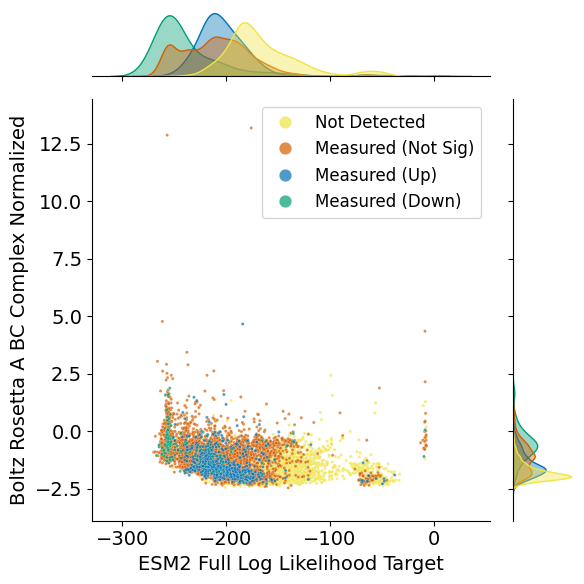

In [144]:
# build plotting df from full metrics_df
plot_df = metrics_df[feat_list + ["global_id", "msa_depth", "amina_solubility"]].copy()
plot_df = plot_df.dropna()

# attach 3 class int labels on same index
plot_df["leah_12k_2fold_threshold_int"] = results_df.loc[
    plot_df.index,
    "leah_12k_2fold_threshold_int",
].values

# map to 4 class labels
def map_four_class(v):
    if pd.isna(v):
        return "Not Detected"
    if v == 0:
        return "Measured (Not Sig)"
    if v == 1:
        return "Measured (Up)"
    if v == -1:
        return "Measured (Down)"
    return "Not Detected"

plot_df["fourclass"] = plot_df["leah_12k_2fold_threshold_int"].apply(map_four_class)

# desired order and colors
order = [
    "Not Detected",
    "Measured (Not Sig)",
    "Measured (Up)",
    "Measured (Down)",
]

palette = {
    "Measured (Down)": "#009E73",
    "Measured (Not Sig)": "#D55E00",
    "Measured (Up)": "#0072B2",
    "Not Detected": "#F0E442",
}
cat_order = {
    "Not Detected": 0,
    "Measured (Not Sig)": 1,
    "Measured (Up)": 2,
    "Measured (Down)": 3,
}

plot_df = plot_df.assign(sort_key=plot_df["fourclass"].map(cat_order))
plot_df = plot_df.sort_values("sort_key", ascending=True)

g = sns.jointplot(
    data=plot_df,
    x=feat_list[0],
    y=feat_list[1],
    hue="fourclass",
    hue_order=order,
    palette=palette,
    kind="scatter",
    s=5,
    alpha=0.7,
    marginal_kws=dict(common_norm=False, fill=True, alpha=0.4),
)

# pretty axis labels
g.ax_joint.set_xlabel(
    feat_list[0]
        .replace("_", " ")
        .title()
        .replace("Ll", "Log Likelihood")
        .replace("Car", "CAR")
        .replace("Esm", "ESM"),
    fontsize=14,
)
g.ax_joint.set_ylabel(
    feat_list[1]
        .replace("_", " ")
        .title()
        .replace("Bc", "BC"),
    fontsize=14,
)

g.ax_joint.tick_params(axis="x", labelsize=14)
g.ax_joint.tick_params(axis="y", labelsize=14)

# legend with larger markers in the right order
leg = g.ax_joint.get_legend()
handles = leg.legend_handles
g.ax_joint.legend(
    handles,
    order,
    markerscale=4,
    fontsize=12,
    title="",
)

plt.tight_layout()
plt.savefig(
    f"../results/analysis/mi_joint_{feat_list[0]}_{feat_list[1]}_4class.png",
    dpi=300,
)

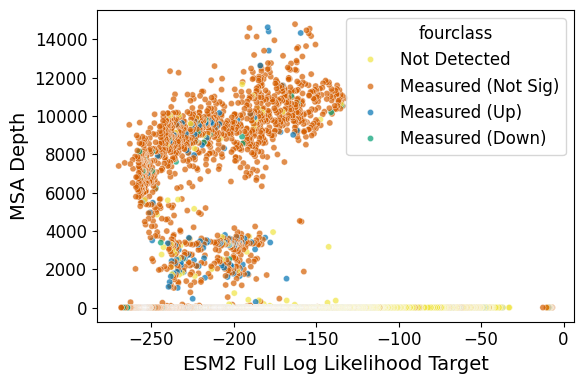

In [151]:
# find the global_ids of the highest esm likelihood of the non detected and print their scores
# DO NOT DO THIS WITH THE INDEX
plot_df.sort_values("esm2_full_LL_target", ascending=False, inplace=True)
plot_df[plot_df["fourclass"] == "Not Detected"].iloc[:20]

# plot the msa depth vs esm2_full_LL_target
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=plot_df,
    x="esm2_full_LL_target",
    y="msa_depth",
    hue="fourclass",
    hue_order=order,
    palette=palette,
    s=20,
    alpha=0.7,
)
plt.ylabel("MSA Depth", fontsize=14)
plt.xlabel("ESM2 Full Log Likelihood Target", fontsize=14)
# plt.xscale("log")
plt.tight_layout()
plt.show()

In [ ]:
plot_df[plot_df["global_id"] == 8573]

,esm2_full_LL_target,boltz_rosetta_A_BC_complex_normalized,global_id,leah_12k_2fold_threshold_int,fourclass,sort_key
8572,-96.751801,-1.587,8573,NaN,Not Detected,0


In [171]:
# print stats on msa_depth for each class
all_df = metrics_df.copy()
all_df = all_df.merge(
    results_df,
    how="left",
    on=["global_id"],
)
all_df["leah_12k_2fold_threshold_int"] = all_df["leah_12k_2fold_threshold"].map(
    {"Up": 1, "Not Sig": 0, "Down": -1, np.nan: np.nan}
)
all_df["fourclass"] = all_df["leah_12k_2fold_threshold_int"].apply(map_four_class)


_feat = "msa_depth"
for cls in order:
    sub_df = all_df[all_df["leah_12k_2fold_threshold_int"].apply(map_four_class) == cls]
    print(f"Class: {cls}")
    print(f"  N: {len(sub_df)}")
    print(f"  MSA Depth: mean={sub_df[_feat].mean():.2f}, median={sub_df[_feat].median():.2f}, std={sub_df[_feat].std():.2f}, min={sub_df[_feat].min():.2f}, max={sub_df[_feat].max():.2f}")
    print()

Class: Measured (Down)
  N: 166
  MSA Depth: mean=1328.20, median=0.00, std=3133.91, min=0.00, max=11036.00

Class: Measured (Not Sig)
  N: 5941
  MSA Depth: mean=1879.96, median=0.00, std=3669.86, min=0.00, max=14784.00

Class: Measured (Up)
  N: 707
  MSA Depth: mean=820.92, median=0.00, std=2364.26, min=0.00, max=14623.00

Class: Not Detected
  N: 5186
  MSA Depth: mean=61.16, median=0.00, std=685.28, min=0.00, max=11649.00



In [177]:
cols = metrics_df.columns.drop(["team", "global_id", "sequence", "closest_ab"]).tolist()

# make col for distinguishing between "Up" and "Not Detected"
def map_up_vs_notdetected(v):
    if v == "Up":
        return True
    return False

results_2_df = results_df.copy()
results_2_df = results_2_df[results_2_df["leah_12k_2fold_threshold"].isin(["Up", np.nan])]
results_2_df["leah_12k_isup_vs_notdetected"] = results_2_df["leah_12k_2fold_threshold"].apply(map_up_vs_notdetected)

metrics_2_df = metrics_df.loc[results_2_df.index]

mi_df = pd.DataFrame()
for col in cols:
    pre_len = len(metrics_2_df)
    metrics_df_col = metrics_2_df[[col]].copy()
    metrics_df_col = metrics_df_col[~metrics_df_col[col].isna()]
    post_len = len(metrics_df_col)
    X = metrics_df_col[col].values.reshape(-1, 1)
    y = results_2_df.loc[metrics_df_col.index, "leah_12k_isup_vs_notdetected"].values
    mi = mutual_info_classif(
        X,
        y,
        random_state=8387234,
        # n_neighbors=5,
        # discrete_features=False,
    )
    sub_df = pd.DataFrame({
        "metric": col,
        "mi_vs_leah_12k_measured": mi,
        "num_non_nan": post_len,
        "num_nan": pre_len - post_len,
    })
    mi_df = pd.concat([mi_df, sub_df], axis=0)

In [181]:
mi_df.sort_values("mi_vs_leah_12k_measured", ascending=False).reset_index(drop=True).to_csv("../results/analysis/_temp_feature_mi_vs_leah_12k_isup_vs_not.csv", index=False)

In [129]:
# plot_df = metrics_df[[feat_list[0], feat_list[1]]].copy()
# plot_df = plot_df.dropna()
# plot_df["leah_12k_measured"] = results_df.loc[
#     plot_df.index,
#     "leah_12k_measured",
# ].values

# # plot_df = plot_df.sort_values("leah_12k_measured", ascending=True)

# g = sns.jointplot(
#     data=plot_df,
#     x=feat_list[0],
#     y=feat_list[1],
#     hue="leah_12k_measured",
#     hue_order=[True, False],
#     # orange then blue
#     palette=["#FF7F0E", "#1F77B4"],
#     kind="scatter",
#     s=4,
#     alpha=0.7,
#     marginal_kws=dict(common_norm=False, fill=True, alpha=0.4),
# )

# g.ax_joint.set_xlabel(feat_list[0].replace("_", " ").title().replace("Ll", "Log Likelihood").replace("Car", "CAR").replace("Esm", "ESM"), fontsize=14)
# g.ax_joint.set_ylabel(feat_list[1].replace("_", " ").title().replace("Bc", "BC"), fontsize=14)
# g.ax_joint.tick_params(axis='x', labelsize=14)
# g.ax_joint.tick_params(axis='y', labelsize=14)

# # make legend dots bigger
# leg = g.ax_joint.get_legend()
# handles = leg.legend_handles
# labels = [t.get_text() for t in leg.get_texts()]

# g.ax_joint.legend(handles, labels, markerscale=4, fontsize=12)

# plt.tight_layout()
# plt.savefig(f"../results/analysis/mi_joint_{feat_list[0]}_{feat_list[1]}.png", dpi=300)

In [130]:
results_df_filtered = results_df[results_df["leah_12k_measured"]].reset_index(drop=True)
results_df_filtered["leah_12k_2fold_threshold_int"] = results_df_filtered["leah_12k_2fold_threshold"].map({"Up": 1, "Not Sig": 0, "Down": -1})
metrics_df_filtered = metrics_df[metrics_df["global_id"].isin(results_df_filtered["global_id"])].reset_index(drop=True)
cols = metrics_df_filtered.columns.drop(["team", "global_id", "sequence", "closest_ab"]).tolist()

mi_df = pd.DataFrame()
for col in cols:
    pre_len = len(metrics_df_filtered)
    metrics_df_col = metrics_df_filtered[[col]].copy()
    metrics_df_col = metrics_df_col[~metrics_df_col[col].isna()]
    post_len = len(metrics_df_col)
    X = metrics_df_col[col].values.reshape(-1, 1)
    y = results_df_filtered.loc[metrics_df_col.index, "leah_12k_2fold_threshold_int"].values
    mi = mutual_info_classif(
        X,
        y,
        random_state=891237,
        # n_neighbors=5,
        # discrete_features=False,
    )
    sub_df = pd.DataFrame({
        "metric": col,
        "mi_vs_leah_12k_2fold_threshold_int": mi,
        "num_non_nan": post_len,
        "num_nan": pre_len - post_len,
    })
    mi_df = pd.concat([mi_df, sub_df], axis=0)
mi_df = mi_df.sort_values("mi_vs_leah_12k_2fold_threshold_int", ascending=False).reset_index(drop=True)
mi_df.to_csv("../results/analysis/feature_mi_vs_leah_12k_2fold_threshold_int_filtered.csv", index=False)

In [131]:
# plot_df = metrics_df_filtered[[feat_list[0], feat_list[1]]].copy()
# plot_df = plot_df.dropna()
# plot_df["leah_12k_2fold_threshold_int"] = results_df_filtered.loc[
#     plot_df.index,
#     "leah_12k_2fold_threshold_int",
# ].values

# g = sns.jointplot(
#     data=plot_df,
#     x=feat_list[0],
#     y=feat_list[1],
#     hue="leah_12k_2fold_threshold_int",
#     hue_order=[-1, 0, 1],
#     # palette = {"Up": "#D97277", "Not Sig": "#BEBEBE", "Down": "#3C53C5"}
#     palette=["#3C53C5", "#BEBEBE", "#D97277"],
#     kind="scatter",
#     s=4,
#     alpha=0.7,
#     marginal_kws=dict(common_norm=False, fill=True, alpha=0.4),
# )

# g.ax_joint.set_xlabel(feat_list[0].replace("_", " ").title().replace("Ll", "Log Likelihood").replace("Car", "CAR").replace("Esm", "ESM"), fontsize=14)
# g.ax_joint.set_ylabel(feat_list[1].replace("_", " ").title().replace("Bc", "BC"), fontsize=14)
# # xtick size
# g.ax_joint.tick_params(axis='x', labelsize=14)
# g.ax_joint.tick_params(axis='y', labelsize=14)

# # make legend dots bigger
# # make legend dots bigger
# leg = g.ax_joint.get_legend()
# handles = leg.legend_handles
# labels = [t.get_text() for t in leg.get_texts()]

# g.ax_joint.legend(handles, labels, markerscale=4, fontsize=12)
# # make labels say: -1: Down, 0: Not Sig, 1: Up
# # make leg order up not sig then down
# label_map = {1: "Up", 0: "Not Sig", -1: "Down"}
# new_labels = [label_map[int(lab)] for lab in labels]
# g.ax_joint.legend(handles, new_labels, markerscale=4, fontsize=12)
# # now fix the order:






# plt.tight_layout()
# plt.savefig(f"../results/analysis/mi_joint_{feat_list[0]}_{feat_list[1]}_postmeasuredfiltered.png", dpi=300)

In [132]:
# # --- combined score calculation ---

# feat_list = ["esm2_full_LL_target", "boltz_rosetta_A_BC_complex_normalized", "amina_solubility"]
# sign_list = [-1.0, 1.0, 1.0]

# metrics_df_sub = metrics_df_filtered[feat_list].copy()
# metrics_df_sub = metrics_df_sub.dropna()

# metrics_df_norm = (metrics_df_sub - metrics_df_sub.mean()) / metrics_df_sub.std()

# joint_score = (metrics_df_norm.values * sign_list).sum(axis=1)

# threeclass = results_df_filtered.loc[
#     metrics_df_sub.index,
#     "leah_12k_2fold_threshold_int",
# ]

# df = pd.DataFrame({
#     "joint_score": joint_score,
#     "class3": threeclass,
# }).dropna()

# feature = "joint_score"
# order = [1, 0, -1]

# palette = {
#     -1: "#3C53C5",
#     0:  "#BEBEBE",
#     1:  "#D97277",
# }

# # --- MI and Pearson ---

# X_joint = df[feature].values.reshape(-1, 1)
# y_joint = df["class3"].values

# mi_joint = mutual_info_classif(
#     X_joint,
#     y_joint,
#     random_state=169873,
# )[0]
# print("MI:", mi_joint)

# pearson_corr, pearson_pval = pearsonr(df[feature].values, y_joint)
# print("Pearson:", pearson_corr, pearson_pval)

# # --- plotting ---

# plt.rcParams.update({'font.size': 12})
# fig, ax = plt.subplots(figsize=(6.5, 4.3))

# sns.violinplot(
#     data=df,
#     x=feature,
#     y="class3",
#     orient="h",
#     order=order,
#     palette=palette,
#     hue="class3",
#     ax=ax,
#     cut=0,
# )

# # counts
# valid = df["class3"].notna() & df[feature].notna()
# dplot = df.loc[valid]
# counts = dplot["class3"].value_counts().reindex(order).fillna(0).astype(int)

# label_map = {
#     1: "Up",
#     0: "Not Sig",
#     -1: "Down",
# }

# new_labels = [f"{label_map[o]}\n(n={counts[o]})" for o in order]

# ax.set_yticks(range(len(order)))
# ax.set_yticklabels(new_labels)
# ax.tick_params(axis='y', length=0)
# ax.set_ylabel("")
# ax.set_xlabel("Joint Score")

# for label in ax.get_yticklabels():
#     label.set_horizontalalignment('center')
#     label.set_x(-0.13)

# # stats comparisons (all pairs)
# pairs = [(-1, 0), (-1, 1), (0, 1)]

# annotator = Annotator(
#     ax,
#     pairs,
#     data=dplot,
#     x=feature,
#     y="class3",
#     order=order,
#     orient="h",
# )
# annotator.configure(
#     test="Mann-Whitney",
#     comparisons_correction="BH",
#     text_format="star",
#     pvalue_thresholds=[(1e-4, "****"), (1e-3, "***"), (1e-2, "**"), (0.05, "*"), (1, "ns")],
#     show_test_name=False,
#     loc="outside",
#     fontsize=11,
#     hide_non_significant=False,
# )
# annotator.apply_and_annotate()

# ax.legend_.remove()

# plt.savefig(
#     f"../results/analysis/mi_jointscore_3class_{feat_list[0]}_{feat_list[1]}.png",
#     dpi=300,
#     bbox_inches='tight'
# )



# # NOTE: Maybe combine w/ Not Detected?

In [133]:
# # make a new metrics df that averages across each "team"
# # remember, we need to get rid of our non-float cols
# metrics_df_grouped = metrics_df.copy().drop(columns=["global_id", "sequence", "closest_ab"])
# metrics_df_grouped = metrics_df_grouped.dropna()
# print(f"Dropped to {len(metrics_df_grouped)} rows after dropping NA")
# metrics_df_grouped = metrics_df_grouped.groupby("team").mean().reset_index()
# metrics_df_grouped = metrics_df_grouped[metrics_df_grouped["team"] != "Leah Labs"].reset_index(drop=True)
# per_team_df = pd.read_csv("../data/good/master_data_teams.csv", usecols=["team", "confidence", "number_of_unique_seqs_submitted", "number_of_significant_seqs", "percent_of_significant_seqs", "12k_hit_rate_ranking"])

In [134]:
# # now compute mutual information for each metric in metrics_df_grouped with per_team_df["percent_of_significant_seqs"] (continuous)

# from sklearn.feature_selection import mutual_info_regression

# # merge team level metrics with team level percent_of_significant_seqs
# merged_df = metrics_df_grouped.merge(
#     per_team_df[["team", "percent_of_significant_seqs"]],
#     on="team",
#     how="inner",
# )

# # all metric columns (everything except team and target)
# metric_cols = merged_df.columns.drop(["team", "percent_of_significant_seqs"])

# mi_rows = []

# for col in metric_cols:
#     pre_len = len(merged_df)

#     sub = merged_df[[col, "percent_of_significant_seqs"]].dropna()
#     post_len = len(sub)

#     X = sub[[col]].values  # shape (n_samples, 1)
#     y = sub["percent_of_significant_seqs"].values  # continuous target

#     mi = mutual_info_regression(
#         X,
#         y,
#         random_state=891237,
#     )[0]

#     mi_rows.append({
#         "metric": col,
#         "mi_vs_percent_of_significant_seqs": mi,
#         "num_non_nan": post_len,
#         "num_nan": pre_len - post_len,
#     })

# mi_df = pd.DataFrame(mi_rows).sort_values(
#     "mi_vs_percent_of_significant_seqs",
#     ascending=False,
# )

# mi_df.sort_values("mi_vs_percent_of_significant_seqs", ascending=False).reset_index(drop=True).to_csv("../results/analysis/feature_mi_vs_percent_of_significant_seqs_per_team.csv", index=False)